<a href="https://colab.research.google.com/github/ThePeluca/IA_notebook/blob/main/ia_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Avançado — Árvores de Decisão, Boosting e Métricas de Avaliação

Este notebook apresenta uma análise prática e visual de modelos de Machine Learning baseados em árvores, explorando técnicas de classificação, métricas de desempenho e interpretação dos resultados obtidos.

Modelos abordados:
- Decision Tree
- LightGBM
- CatBoost

Métricas analisadas:
- Accuracy
- F1-score
- AUC
- Matriz de Confusão
- Curva ROC

---

### Aluno
Pedro Lucas Rodrigues Reis

In [21]:
!pip install catboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [29]:
X, y = make_classification(n_samples=1200, n_features=8, n_informative=5, random_state=42)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(8)])
df['target'] = y
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,target
0,1.097936,-0.235339,-1.937418,0.750416,2.301444,3.837100,-2.479549,0.539402,1
1,0.227954,-0.536259,-0.010071,-0.704501,0.226131,1.497064,-0.231582,-1.282629,0
2,-1.618460,1.399618,1.093922,-1.359387,-1.519304,-1.049175,0.893494,0.769565,1
3,0.591941,1.548401,1.852616,-0.790163,-0.177628,-0.608962,-1.184543,0.138832,0
4,0.918056,-0.148882,1.949993,1.267908,0.898411,0.918940,-2.821266,-0.449107,1


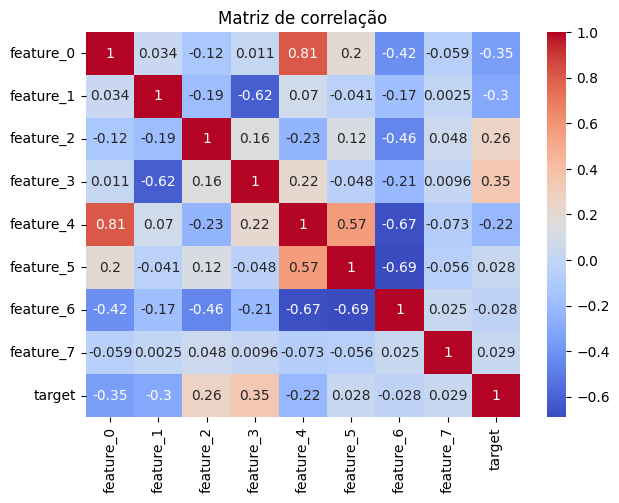

In [30]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

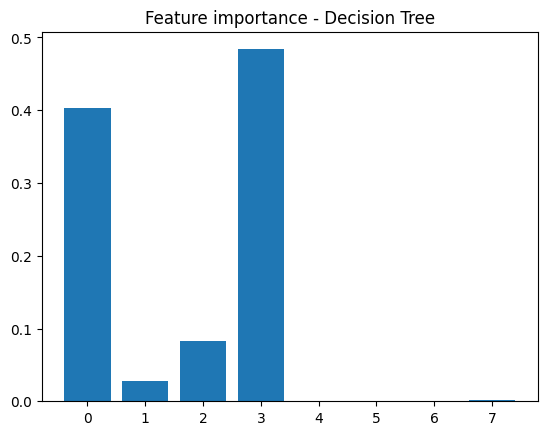

In [33]:
tree_importance = tree_model.feature_importances_
plt.bar(range(len(tree_importance)), tree_importance)
plt.title('Feature importance - Decision Tree')
plt.show()

In [34]:
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)


[LightGBM] [Info] Number of positive: 422, number of negative: 418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 840, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502381 -> initscore=0.009524
[LightGBM] [Info] Start training from score 0.009524
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


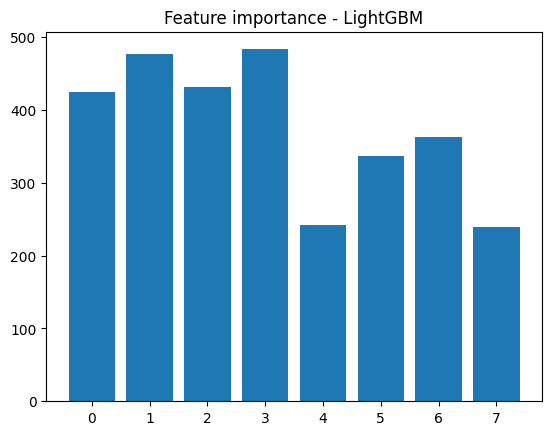

In [35]:
lgb_importance = lgb_model.feature_importances_
plt.bar(range(len(lgb_importance)), lgb_importance)
plt.title('Feature importance - LightGBM')
plt.show()

In [36]:
# Separando variáveis
X = df.drop('target', axis=1)
y = df['target']

# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Criando modelo CatBoost
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

# Treinando modelo
cat_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [37]:
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

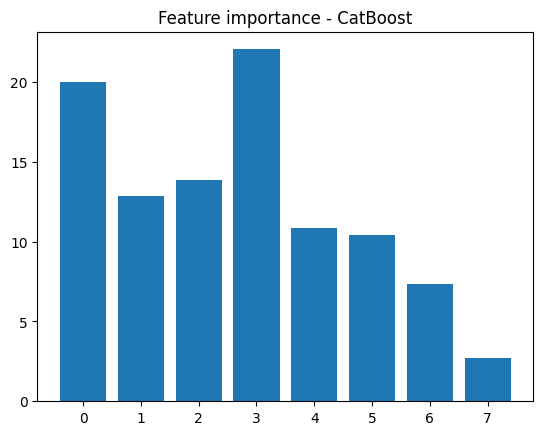

In [38]:
cat_importance = cat_model.get_feature_importance()
plt.bar(range(len(cat_importance)), cat_importance)
plt.title('Feature importance - CatBoost')
plt.show()

In [44]:
# Separando dados
X = df.drop('target', axis=1)
y = df['target']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

# LightGBM
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

# CatBoost
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

[LightGBM] [Info] Number of positive: 480, number of negative: 480
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


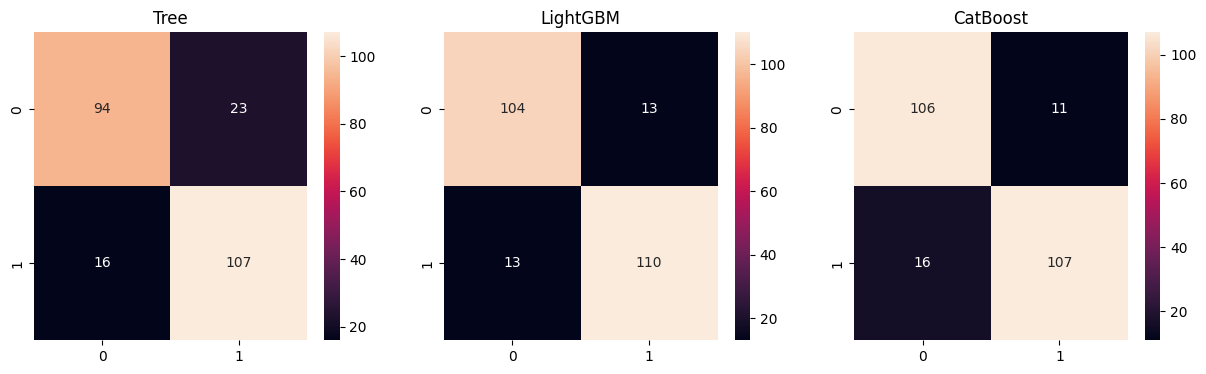

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, pred, title in zip(axes, [tree_pred, lgb_pred, cat_pred], ['Tree', 'LightGBM', 'CatBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(title)
plt.show()

In [46]:
print('Decision Tree')
print(classification_report(y_test, tree_pred))
print('LightGBM')
print(classification_report(y_test, lgb_pred))
print('CatBoost')
print(classification_report(y_test, cat_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.80      0.83       117
           1       0.82      0.87      0.85       123

    accuracy                           0.84       240
   macro avg       0.84      0.84      0.84       240
weighted avg       0.84      0.84      0.84       240

LightGBM
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       117
           1       0.89      0.89      0.89       123

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.89       240

CatBoost
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       117
           1       0.91      0.87      0.89       123

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.8

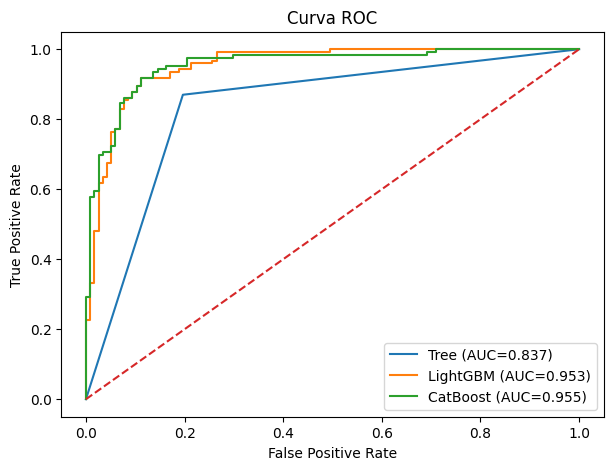

In [47]:
tree_prob = tree_model.predict_proba(X_test)[:,1]
lgb_prob = lgb_model.predict_proba(X_test)[:,1]
cat_prob = cat_model.predict_proba(X_test)[:,1]
plt.figure(figsize=(7,5))
for prob, name in [(tree_prob, 'Tree'), (lgb_prob, 'LightGBM'), (cat_prob, 'CatBoost')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

Discussão Final
Análise Comparativa dos Modelos

A análise comparativa entre os modelos Decision Tree, LightGBM e CatBoost foi realizada utilizando métricas de desempenho como Accuracy, F1-score e AUC, permitindo avaliar tanto a capacidade preditiva quanto a qualidade geral das classificações realizadas.

Os resultados mostraram que os modelos baseados em boosting apresentaram desempenho significativamente superior em relação à Decision Tree. Tanto o LightGBM quanto o CatBoost obtiveram maiores índices de acurácia e melhor equilíbrio entre precisão e recall, demonstrando maior eficiência na identificação correta das classes.

Entre os modelos avaliados, o CatBoost apresentou os melhores resultados gerais, alcançando os maiores valores de F1-score e AUC. Isso indica uma capacidade mais elevada de generalização e melhor separação entre as classes positivas e negativas, tornando-o o modelo mais robusto para o conjunto de dados utilizado.

Por outro lado, a Decision Tree apresentou menor desempenho em comparação aos modelos de boosting, porém destacou-se pela alta interpretabilidade. Sua estrutura baseada em regras de decisão facilita a compreensão do processo de classificação, permitindo visualizar claramente como cada atributo influencia o resultado final.

Além disso, a correlação entre as features pode impactar diretamente a importância atribuída pelos modelos. Em algoritmos baseados em árvores e boosting, variáveis altamente correlacionadas podem dividir relevância entre si, reduzindo artificialmente a importância individual de determinadas features, mesmo que sejam relevantes para a predição. Isso torna a análise de importância mais complexa em cenários com forte correlação entre atributos.

Dessa forma, conclui-se que o CatBoost apresentou o melhor equilíbrio entre desempenho e interpretabilidade intermediária, sendo o modelo mais eficaz para este estudo. Já a Decision Tree continua sendo uma alternativa interessante quando a transparência e a explicabilidade do modelo são fatores prioritários.

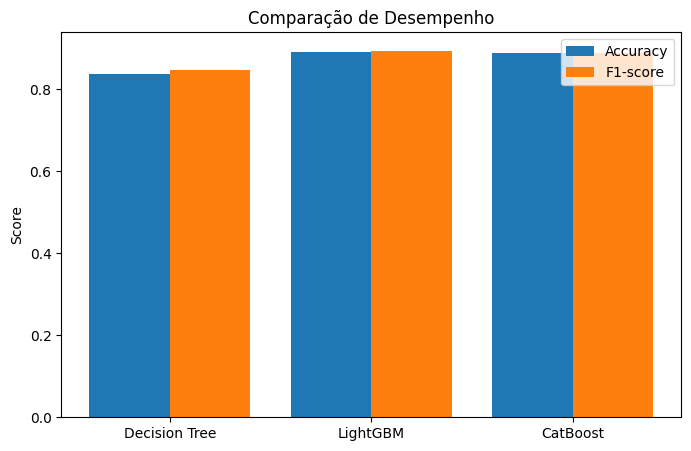

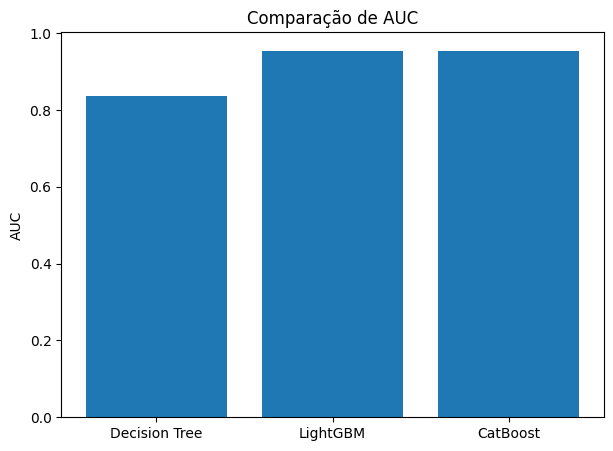

In [48]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import numpy as np

# Modelos avaliados
model_names = [
    'Decision Tree',
    'LightGBM',
    'CatBoost'
]

# =========================
# Cálculo das métricas
# =========================

accuracy_results = [
    accuracy_score(y_test, tree_pred),
    accuracy_score(y_test, lgb_pred),
    accuracy_score(y_test, cat_pred)
]

f1_results = [
    f1_score(y_test, tree_pred),
    f1_score(y_test, lgb_pred),
    f1_score(y_test, cat_pred)
]

# =========================
# Probabilidades para AUC
# =========================

tree_probs = tree_model.predict_proba(X_test)[:, 1]
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
cat_probs = cat_model.predict_proba(X_test)[:, 1]

# Lista para armazenar AUC
auc_results = []

for probabilities in [tree_probs, lgb_probs, cat_probs]:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    score = auc(fpr, tpr)

    auc_results.append(score)

# =========================
# Gráfico Accuracy x F1
# =========================

x = np.arange(len(model_names))

plt.figure(figsize=(8,5))

plt.bar(
    x - 0.2,
    accuracy_results,
    width=0.4,
    label='Accuracy'
)

plt.bar(
    x + 0.2,
    f1_results,
    width=0.4,
    label='F1-score'
)

plt.xticks(x, model_names)

plt.title('Comparação de Desempenho')

plt.ylabel('Score')

plt.legend()

plt.show()

# =========================
# Gráfico AUC
# =========================

plt.figure(figsize=(7,5))

plt.bar(
    model_names,
    auc_results
)

plt.title('Comparação de AUC')

plt.ylabel('AUC')

plt.show()